#Why Gradient descent??

Gradient descent is also used to find out the right value of m and b so that there is no need to use OLS(ordinary least squares) since it invloves inversing the matrix operation which is very heavy and requirees almost 100 crore operations to find inverse of a matrix for a large data that's why gradient descent is used!

In [5]:
from sklearn.datasets import make_regression
import numpy as np

In [6]:
X,y = make_regression (n_samples=4, n_features=1, n_informative=1,n_targets=1,noise=80, random_state=12)

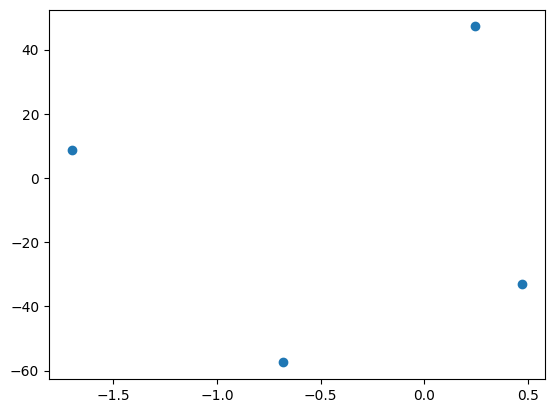

In [7]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

# Applying OLS to find out the value of m:

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
reg = LinearRegression()
reg.fit(X,y)

LinearRegression()

In [10]:
reg.coef_

array([1.9727935])

In [11]:
reg.intercept_

np.float64(-7.816786196244997)

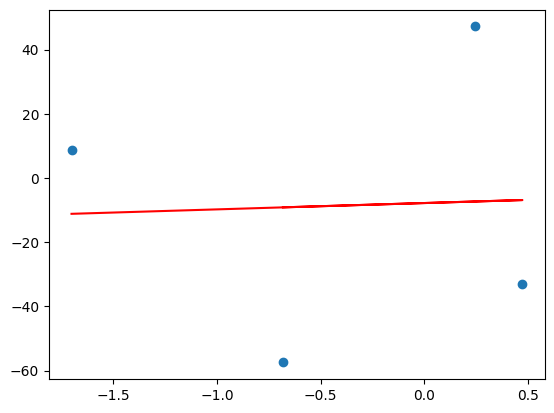

In [12]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red')

## the value of slope is 1.9727935 and value of intercept is -7.816786244997
we will now use gradient descent and find out the value of b for which the value of loss function is min.
## assuming the starting value for intercept b=0

In [13]:
y_pred =((1.9727935*X)+0).reshape(4)

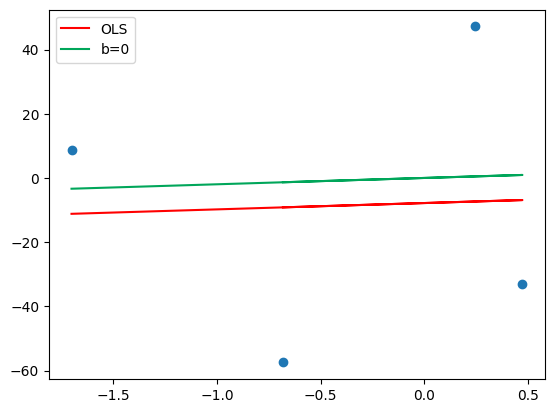

In [14]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label="OLS")
plt.plot(X,y_pred,color="#00a65a",label='b=0')
plt.legend()
plt.show()


In [15]:
m=1.9727935
b=0
loss_slope =-2*np.sum(y-m*X.ravel()-b)
loss_slope

np.float64(62.53428958147046)

In [16]:
#lets take learning rate as 0.01
lr=0.01

step_size = loss_slope*lr
step_size

np.float64(0.6253428958147046)

In [19]:
#calculating the new  intercept
b=b-step_size
b

np.float64(-1.2506857916294092)

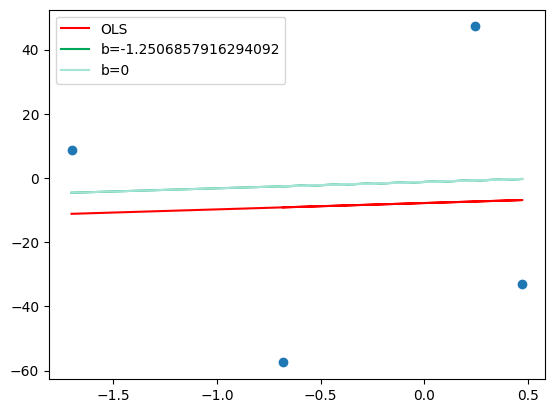

In [25]:
y_pred1 =((1.9727935 *X)+b).reshape(4)
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred1,color="#00a65a",label='b={}'.format(b))
plt.plot(X,y_pred,color="#A3E4D7",label="b=0")
plt.legend()
plt.show()

In [26]:
#Iteration -2
loss_slope=loss_slope*lr
loss_slope

np.float64(0.6253428958147046)

In [31]:
step_size=loss_slope *lr
step_size

np.float64(0.006253428958147046)

In [33]:
b=b-step_size
b

np.float64(-1.2694460785038504)

In [41]:
y_pred2=((1.9727935 *X)+b).reshape(4)

In [34]:
#iteration-3
loss_slope =-2*np.sum(y-m*X.ravel()-b)
loss_slope


np.float64(52.378720953439675)

In [35]:
step_size=loss_slope *lr
step_size

np.float64(0.5237872095343967)

In [37]:
b=b-step_size
b


np.float64(-2.317020497572644)

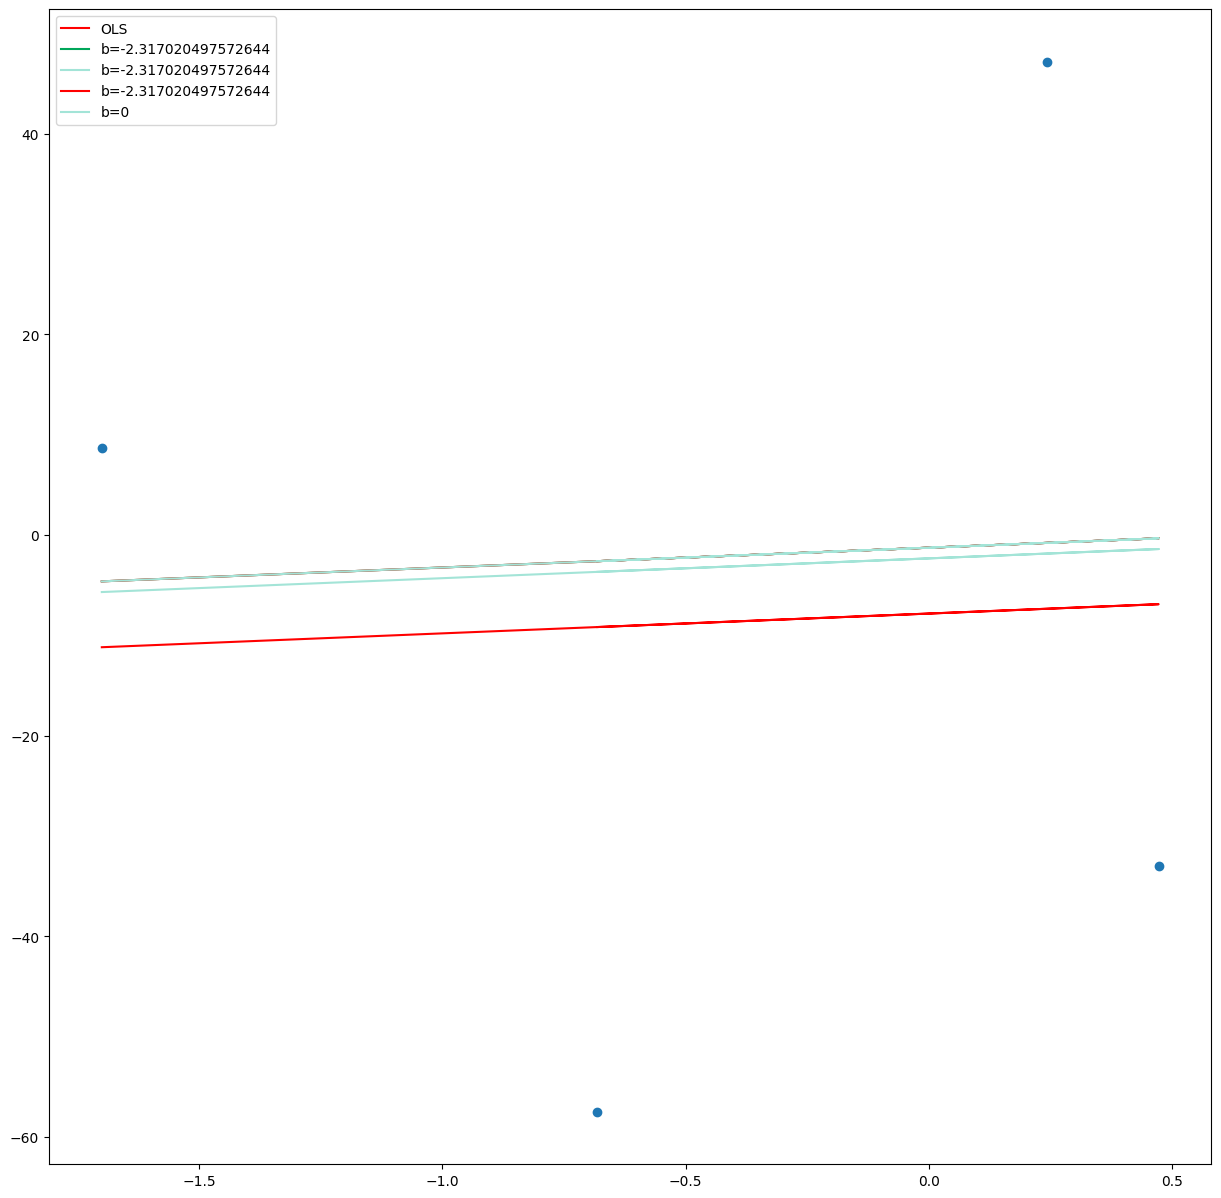

In [42]:
y_pred3= ((1.9727935 *X)+b).reshape(4)

plt.figure (figsize=(15,15))
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred1,color="#00a65a",label='b={}'.format(b))
plt.plot(X,y_pred2,color="#A3E4D7",label='b={}'.format(b))
plt.plot(X,y_pred1,color='red',label="b={}".format(b))
plt.plot(X,y_pred,color="#A3E4D7",label="b=0")
plt.legend()
plt.show()

## we will eventually get very much close to the red line(OLS)

## as soon as green and red line overlap each other then we can say that we have found value of b (min value)

# Writing all of this in a loop-

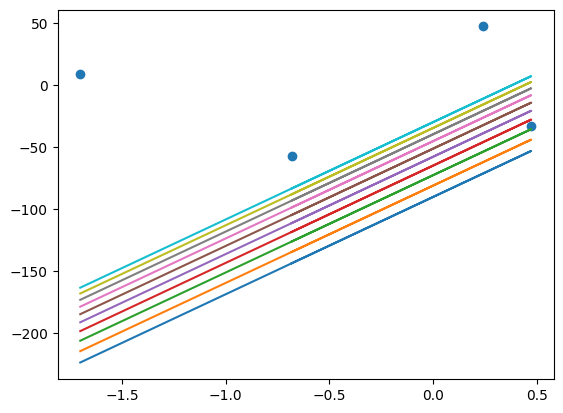

In [45]:
b=-100
m= 78.35
lr=0.01

epochs=10
for i in range(epochs):
  loss_slope=-2 * np.sum(y-m*X.ravel()-b)
  b=b-(lr* loss_slope)
  y_pred =m*X +b

  plt.plot(X,y_pred)
plt.scatter(X,y)